# 2.3 Descriptive Temporal Analysis

In this notebook we analyze the taxi trip data provided by the city of chicago: https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data (downloaded on 05.05.2026), together with the weather data from archive-api.open-meteo.com (downloaded on 28.05.2026).

### Data Requirements:

This notebook requires the following files: 

`01_06_trips_weather_merged.parquet` — local path: `data/merged/01_06_trips_weather_merged.parquet` — Sciebo path: `data_parquet/merged/01_06_trips_weather_merged.parquet`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [1]:
import pandas as pd
import numpy as np
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# reset working dir
import os
from pathlib import Path

In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\Yannick Herrmann\Documents\Uni\AAA\AAA_Project\AAA_TA_2026


In [3]:
# check whether real data exists, else use sampled data
if Path("data/merged/01_06_trips_weather_merged.parquet").exists():
    df = pd.read_parquet("data/merged/01_06_trips_weather_merged.parquet")
else:
    df = pd.read_parquet("data/samples/SAMPLE_01_06_trips_weather_merged.parquet")

df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,<NA>,<NA>,8,8,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,<NA>,<NA>,76,6,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,<NA>,<NA>,8,7,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,<NA>,<NA>,22,7,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,<NA>,<NA>,8,3,...,0.0,0.0,0.0,985.901917,100.0,12.976239,21.575987,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 41 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         string        
 7   dropoff_census_tract        string        
 8   pickup_community_area       int64         
 9   dropoff_community_area      int64         
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

In [5]:
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])
df["trip_start_hour"] = pd.to_datetime(df["trip_start_hour"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 41 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         string        
 7   dropoff_census_tract        string        
 8   pickup_community_area       int64         
 9   dropoff_community_area      int64         
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

## 2.5.1 General Trip feature analysis

### Demand distribution by hour of day:

In [7]:
df["start_month"] = df["trip_start_timestamp"].dt.month
df["start_hour"] = df["trip_start_timestamp"].dt.hour


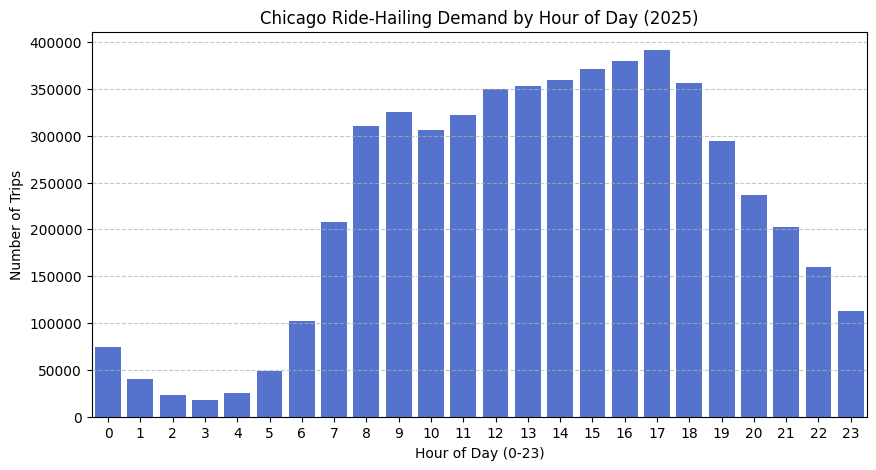

In [ ]:
#| label: fig-demand-by-hour
#| fig-cap: "Chicago Ride-Hailing Demand by Hour of Day"

# Calculate hourly distribution
hourly_counts = df['start_hour'].value_counts().sort_index()

# Plot the hourly demand
plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Hour of Day (2025)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation

Demand follows a clear pattern with a morning peak around 8-9h and a dominant evening peak at 17h. Demand drops sharply during night hours (1-4h) to its lowest levels. The pattern reflects standard commuter behavior, with trips concentrating around the start and end of the working day. Notably there is no sharp midday dip, suggesting a substantial share of non-commuter trips throughout the day.

### Demand distribution by weekday:

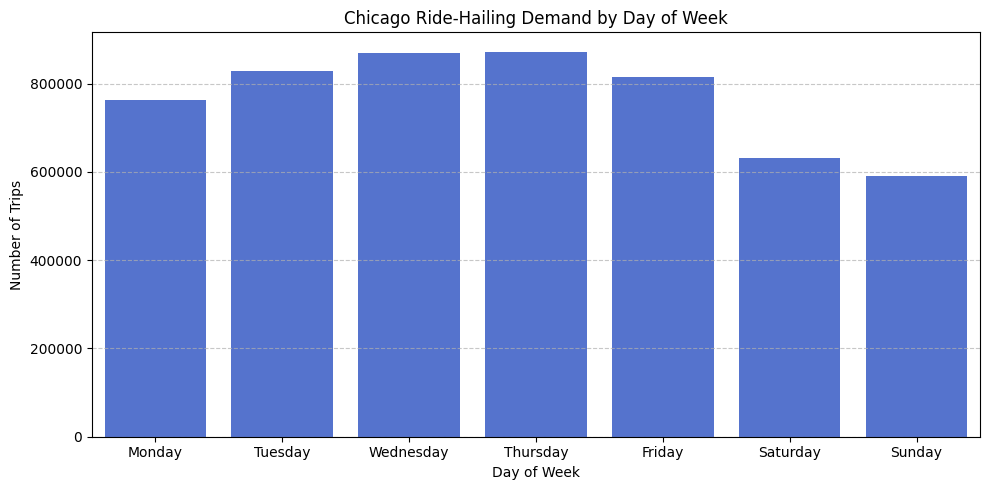

In [ ]:
#| label: fig-demand-by-day
#| fig-cap: "Chicago Ride-Hailing Demand by Day of Week"

# 1. Extract day name
df['day_name'] = df['trip_start_timestamp'].dt.day_name()

# Define categorical orders so your charts don't sort alphabetically (e.g., Friday before Monday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate day of week distribution and reindex to force Mon->Sun order
dow_counts = df['day_name'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation

Weekdays dominate demand, with Wednesday and Thursday being the busiest days. Saturday and Sunday are significantly lower. This is somewhat counterintuitive since one might expect weekends to be busy due to nightlife, but it reflects that Chicago taxi demand is primarily business and commuter driven rather than leisure driven. The Monday dip compared to Tuesday-Thursday likely reflects a slower start to the working week.

### Demand distribution by Month:

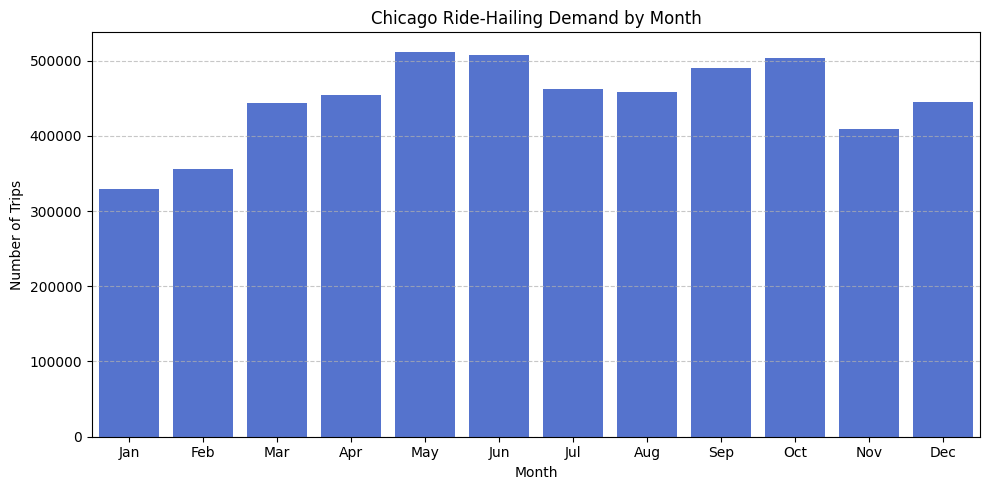

In [ ]:
#| label: fig-demand-by-month
#| fig-cap: "Chicago Ride-Hailing Demand by Month"

# Calculate monthly distribution
df["start_month"] = df["trip_start_timestamp"].dt.month
month_counts = df['start_month'].value_counts().sort_index()

# Map the numeric indices (1-12) to month names (Jan-Dec)
x_labels = [month_names[m - 1] for m in month_counts.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels, y=month_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation

Demand is lowest in winter (January, February) and peaks in spring and early summer (May and June) and again in October. The summer dip in July-August is modest. The winter low likely reflects reduced activity in cold weather combined with fewer business trips around the holiday season. The spring and autumn peaks align with high business activity and favorable weather conditions encouraging more urban mobility.

### day of week vs hour of day demand heatmap:

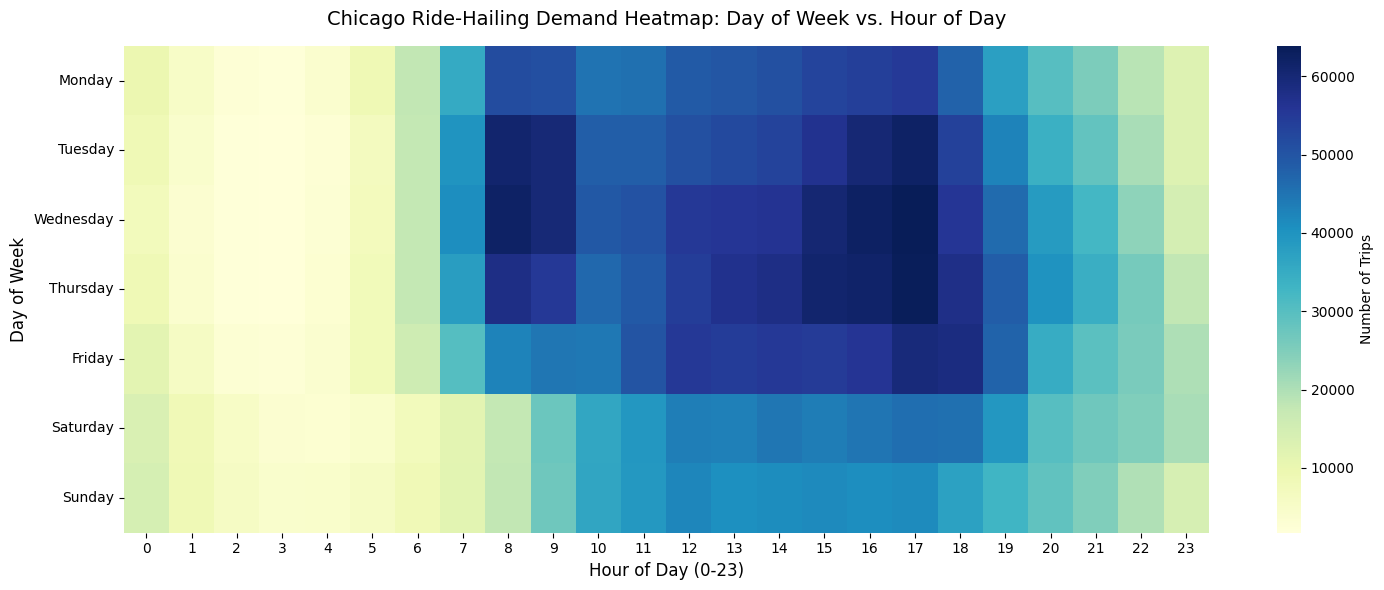

In [ ]:
#| label: fig-demand-heatmap
#| fig-cap: "Chicago Ride-Hailing Demand Heatmap: Day of Week vs Hour of Day"

# Create a pivot table counting trips (using trip_id as the counter)
heatmap_data = df.pivot_table(
    index='day_name', 
    columns='start_hour', 
    values='trip_id', 
    aggfunc='count'
).reindex(day_order) # Ensures Monday to Sunday top-down order

plt.figure(figsize=(15, 6))

sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt="d", cbar_kws={'label': 'Number of Trips'})

plt.title('Chicago Ride-Hailing Demand Heatmap: Day of Week vs. Hour of Day', fontsize=14, pad=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation

Weekday mornings and evenings (8-9h and 16-17h, Tuesday-Thursday) are the single busiest cells, driven by the commuter morning rush and the end of the work-day. Weekends show a fundamentally different pattern: demand is more evenly spread across midday and afternoon hours with no sharp morning spike, consistent with leisure rather than commuter trips.

### Average hourly demand: Weekday vs Weekend

Text(0.5, 1.0, 'Average Hourly Demand: Weekday vs Weekend')

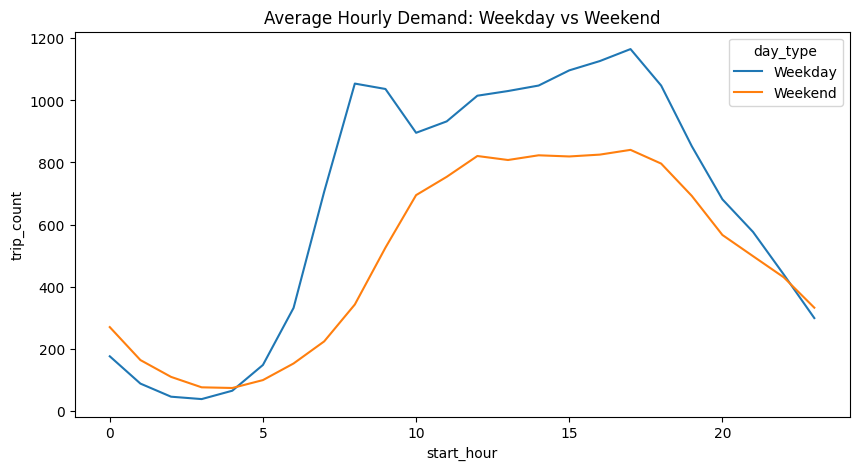

In [12]:
df["day_of_week"] = df["trip_start_timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"] >= 5

avg_demand_week = (
    df.groupby(["trip_start_hour", "is_weekend"])
      .size()
      .reset_index(name="trip_count")
)
avg_demand_week["start_hour"] = avg_demand_week["trip_start_hour"].dt.hour

avg_demand_week = avg_demand_week.groupby(["start_hour", "is_weekend"])["trip_count"].mean().reset_index()

avg_demand_week["day_type"] = avg_demand_week["is_weekend"].map({True: "Weekend", False: "Weekday"})

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_demand_week, x="start_hour", y="trip_count", hue="day_type")
plt.title("Average Hourly Demand: Weekday vs Weekend")

#### Interpretation

The two curves show fundamentally different demand profiles. Weekdays have a sharp morning spike at 7-8h driven by commuters, a slight midday dip around 9-10h, then a sustained high plateau through the afternoon peaking at 17h. Weekends have no morning spike at all. The demand grows gradually and plateaus between 10h and 17h, consistent with leisure activity spread across the day. The weekend curve shows more trips during the night, which can be explained by more night activity during the weekend.

### General distribution of Idle Times Before a Trip

In [13]:
print("Step 1: Converting timestamps to datetime objects...")
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])

print("Step 2: Sorting dataset chronologically per taxi...")
df = df.sort_values(by=['taxi_id', 'trip_start_timestamp']).reset_index(drop=True)

print("Step 3: Finding the end time of each taxi's previous trip...")
df['prev_trip_end'] = df.groupby('taxi_id')['trip_end_timestamp'].shift(1)

print("Step 4: Calculating idle time in minutes...")
time_diff = df['trip_start_timestamp'] - df['prev_trip_end']
df['idle_time_before_start'] = time_diff.dt.total_seconds() / 60.0

print("Step 5: Actively cleaning and fixing data anomalies...")

# Explicitly count and drop the first trip of every taxi since history is unknown
n_before_anomaly_a = len(df)
df = df.dropna(subset=['idle_time_before_start']).reset_index(drop=True)
dropped_first_trips = n_before_anomaly_a - len(df)

# Overlapping trips: force negative idle times to 0 minutes
overlap_count = (df['idle_time_before_start'] < 0).sum()
df.loc[df['idle_time_before_start'] < 0, 'idle_time_before_start'] = 0

# Off-duty shifts: If a gap is > 2 hours, it's a break. Set to NaN so it doesn't pollute averages.
break_count = (df['idle_time_before_start'] > 120).sum()
df.loc[df['idle_time_before_start'] > 120, 'idle_time_before_start'] = np.nan

print("Step 6: Dropping temporary columns to preserve RAM...")
df = df.drop(columns=['prev_trip_end'])

# --- Final Verification ---
missing_values = df['idle_time_before_start'].isnull().sum()

print("\n Extraction & Cleaning Complete!")
print(f"-> Anomaly A Fixed: Dropped {dropped_first_trips} 'first trips' that had no prior history.")
print(f"-> Anomaly B Fixed: Corrected {overlap_count} overlapping trip timestamps to 0 minutes.")
print(f"-> Isolated {break_count} off-duty shifts as NaN to protect future averages.")

Step 1: Converting timestamps to datetime objects...
Step 2: Sorting dataset chronologically per taxi...
Step 3: Finding the end time of each taxi's previous trip...
Step 4: Calculating idle time in minutes...
Step 5: Actively cleaning and fixing data anomalies...
Step 6: Dropping temporary columns to preserve RAM...

 Extraction & Cleaning Complete!
-> Anomaly A Fixed: Dropped 3035 'first trips' that had no prior history.
-> Anomaly B Fixed: Corrected 51254 overlapping trip timestamps to 0 minutes.
-> Isolated 1317561 off-duty shifts as NaN to protect future averages.


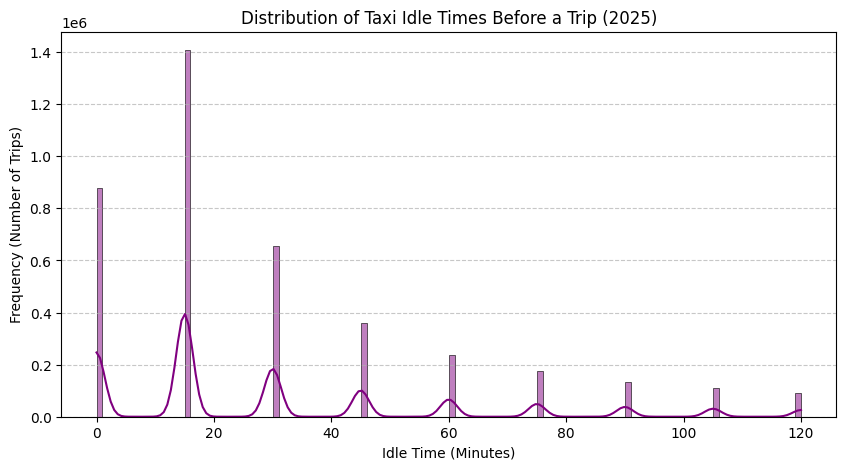

In [ ]:
#| label: fig-idle-distribution
#| fig-cap: "Distribution of Taxi Idle Times before a Trip"

### General distribution of Idle Times Before a Trip
plt.figure(figsize=(10, 5))
# We limit the x-axis to 120 minutes to zoom in on the most common wait times
sns.histplot(df['idle_time_before_start'].dropna(), bins=120, binrange=(0, 120), color='purple', kde=True)

plt.title('Distribution of Taxi Idle Times Before a Trip (2025)')
plt.xlabel('Idle Time (Minutes)')
plt.ylabel('Frequency (Number of Trips)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation

The distribution shows sharp spikes at regular 15-minute intervals, which is a direct consequence of the dataset's trip timestamps being rounded to the nearest 15 minutes. Setting aside this artifact, the underlying distribution indicates that most drivers find their next passenger relatively quickly (>20 min), with a long tail of longer waits extending to the 120-minute preprocessing cutoff.

### Average Idle Time by hour of day

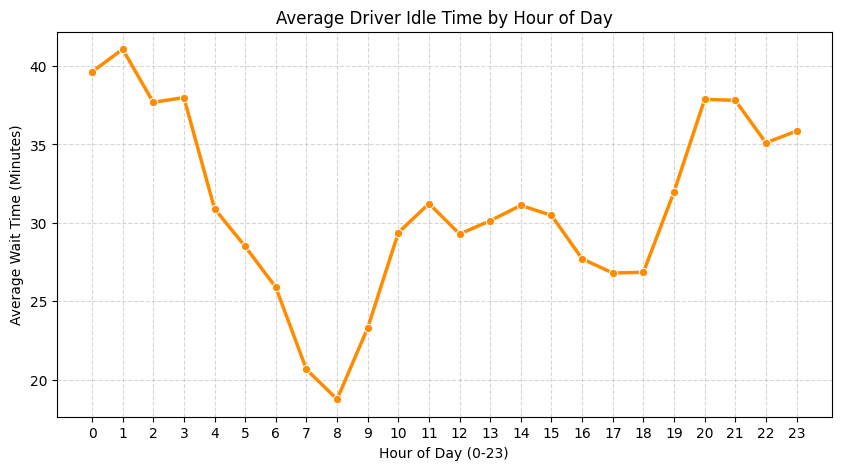

In [15]:
# Calculate the average idle time for each hour of the day
# Pandas naturally ignores our NaNs when calculating the mean!
hourly_idle = df.groupby('start_hour')['idle_time_before_start'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_idle.index, y=hourly_idle.values, marker='o', color='darkorange', linewidth=2.5)

plt.title('Average Driver Idle Time by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Wait Time (Minutes)')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.show()

#### Interpretation

Idle time is highest during night hours (0-3h) when demand is low and drivers must wait longer between trips. It drops sharply to its minimum at 8-9h coinciding with the morning rush when demand peaks and drivers pick up passengers quickly. After 9h idle time rises again to a plateau and drops again when the work day is over (~17h), then rises sharply again in the evening (20-21h).

In [16]:
# 1. Create a new column for trip duration in minutes
df['trip_minutes'] = df['trip_seconds'] / 60

# 2. Configure pandas to format float outputs cleanly (suppressing scientific notation)
# This rounds numbers to 2 decimal places across the board
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 3. Select our operational columns (swapping seconds for minutes)
operational_cols = ['trip_miles', 'trip_minutes', 'trip_total']

# 4. Generate the clean percentile breakdown
operational_summary = df[operational_cols].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

# Rename the index/columns for presentation-ready output
operational_summary.columns = ['Trip Distance (Miles)', 'Trip Duration (Minutes)', 'Total Ticket ($)']
print("=== Fleet Operations Analysis Summary ===")
print(operational_summary)

=== Fleet Operations Analysis Summary ===
       Trip Distance (Miles)  Trip Duration (Minutes)  Total Ticket ($)
count             5366321.00               5366321.00        5366321.00
mean                    6.47                    19.77             24.18
std                     6.20                    14.29             18.25
min                     0.34                     3.23              4.25
25%                     1.42                     9.00             10.50
50%                     3.33                    15.07             15.90
75%                    11.30                    26.55             32.40
90%                    16.96                    40.83             55.20
95%                    17.95                    50.22             60.25
99%                    21.25                    65.90             74.10
max                    43.71                    75.72             95.00


### Correlation Matrix of trip Metrics:

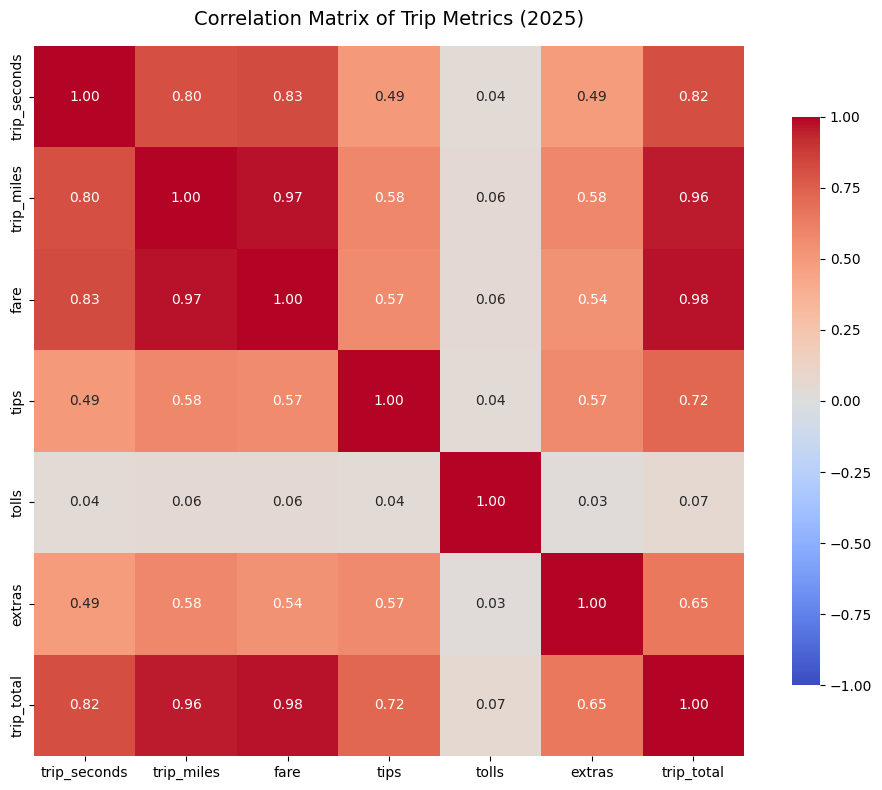

In [17]:
# 1. Isolate the true numeric continuous features
trip_numeric_cols = [
    'trip_seconds', 'trip_miles', 'fare', 
    'tips', 'tolls', 'extras', 'trip_total'
]

# Calculate correlation on the 5.5 million rows (focusing only on these columns is fast!)
trip_corr = df[trip_numeric_cols].corr()

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    trip_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True, 
    vmin=-1, vmax=1, # Forces scale from -1 to 1
    cbar_kws={'shrink': .8}
)

plt.title('Correlation Matrix of Trip Metrics (2025)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### Interpretation

Trip miles and fare are nearly perfectly correlated (0.97), confirming that Chicago taxi fares are metered and distance-based. Trip duration (trip_seconds) correlates strongly with both miles (0.80) and fare (0.83), reflecting that longer trips take more time and cost more. Tips correlate moderately with fare (0.57) and miles (0.58), suggesting passengers tip more on longer, pricier trips but with considerable variation. Tolls are nearly uncorrelated with everything (0.03-0.06), which makes sense since tolls are route-dependent rather than distance-dependent. Extras show moderate correlation with tips and miles (0.57-0.58), likely because extras such as airport surcharges co-occur with longer trips.

## 2.5.2 Visualizations of trip vs weather

### Average trips per hour by Precipitation Intensity

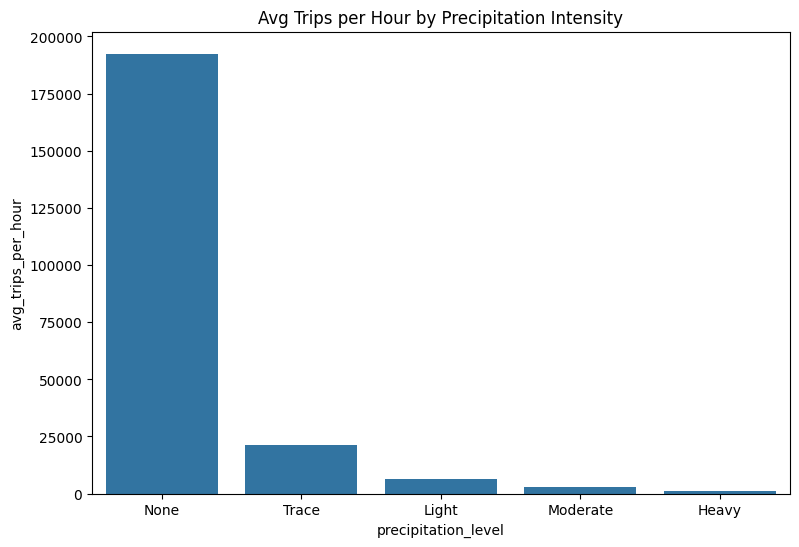

In [ ]:
# Bin continuous precipitation values into categorical intensity levels.
df['precipitation_level'] = pd.cut(
    df['precipitation'],
    bins=[-0.001, 0, 0.5, 2, 5, 100],
    labels=['None', 'Trace', 'Light', 'Moderate', 'Heavy']
)

precipitation_rate = (
    df.groupby(['precipitation_level', 'start_hour'])
      .size()
      .groupby('precipitation_level')
      .mean()
      .reset_index(name='avg_trips_per_hour')
)

plt.figure(figsize=(9, 6))
sns.barplot(data = precipitation_rate, x = "precipitation_level", y="avg_trips_per_hour")
plt.title('Avg Trips per Hour by Precipitation Intensity')
plt.xticks(rotation=0)
plt.show()

#### Interpretation

The vast majority of trips occur during dry conditions, which is expected since dry hours vastly outnumber rainy hours over the year. The sharp drop from None to Trace/Light/Moderate/Heavy does not mean rain reduces demand, it simply reflects that heavy rain is rare. This chart does not visualize the effect of rain on demand.

### Average demand per hour, dry vs rainy:

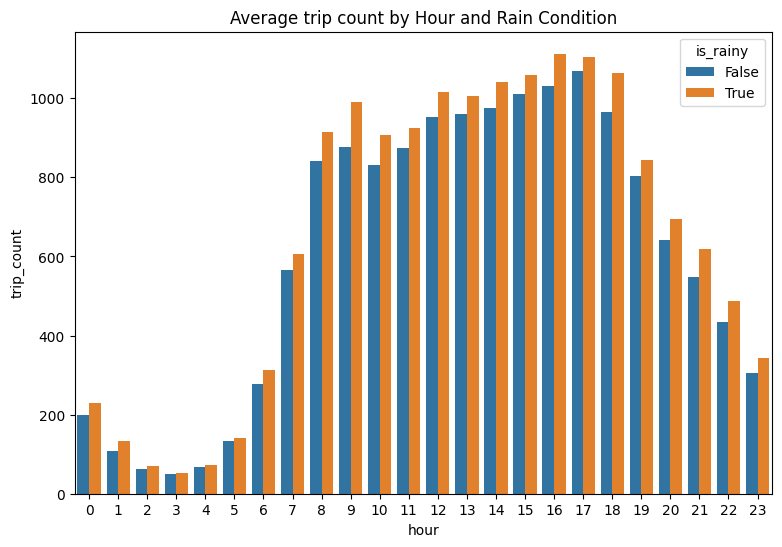

In [ ]:
#| label: fig-rain-demand
#| fig-cap: "Average trip count by Hour and Rain Condition"

df["is_rainy"] = df["rain"] > 0

# Count trips per (timestamp-hour, rain status) combination
hourly_demand = (
    df.groupby(["trip_start_hour", "is_rainy"])
      .size()
      .reset_index(name="trip_count")
)

hourly_demand["hour"] = hourly_demand["trip_start_hour"].dt.hour

# Average trip count per hour and rain status
avg_demand = (
    hourly_demand.groupby(["hour", "is_rainy"])["trip_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_demand, x = "hour", y="trip_count", hue = "is_rainy")
plt.title("Average trip count by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain consistently increases trip demand across all hours of the day. The orange bars are higher than the blue bars at virtually every hour, with the effect most pronounced during peak hours (8-9h and 16-17h). This makes intuitive sense, since people who might otherwise walk, cycle, or use public transit switch to taxis when it rains.

### Average trip duration per hour, dry vs rainy:

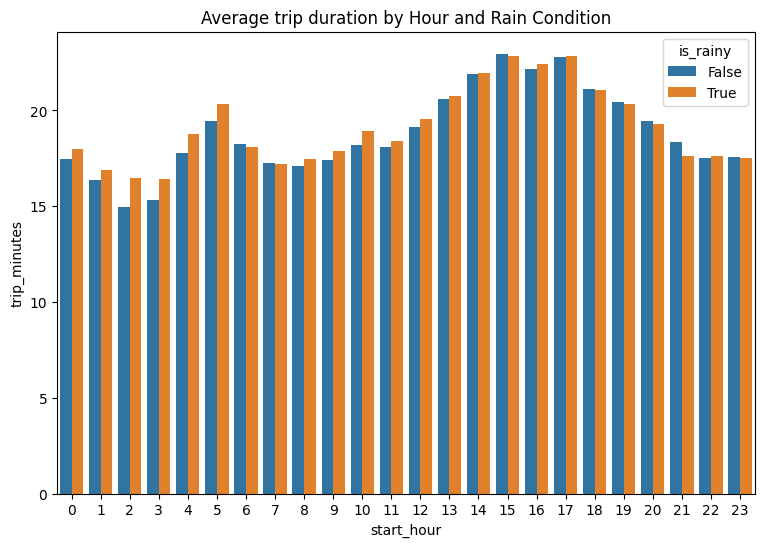

In [ ]:
#| label: fig-rain-duration
#| fig-cap: "Average trip duration by Hour and Rain Condition"

# Average duration per hour and rain status
avg_duration = (
    df.groupby(["start_hour", "is_rainy"])["trip_minutes"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_duration, x = "start_hour", y="trip_minutes", hue = "is_rainy")
plt.title("Average trip duration by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain has a small but consistent effect on trip duration, with rainy trips being slightly longer at most hours. The difference is most visible during the morning (5-6h) peak. This likely reflects increased traffic congestion during rain, which slows down travel and extends trip duration even for the same origin-destination pair. 

The overall hourly distribution shows an interesting pattern. There is a notable peak at 4-5am which is counterintuitive at first glance, but is explained by the airport effect: trips starting at that hour are disproportionately early morning airport runs, where passengers catching early flights travel long distances from residential areas to O'Hare or Midway. Since almost no short urban trips occur at that hour, the average is pulled up by these long-distance trips. As the morning progresses and more short urban trips enter the mix, the average drops before rising again during afternoon hours (14-17h) when traffic congestion is at its peak, extending trip durations regardless of distance.

### Average trip distance per hour, dry vs rainy:

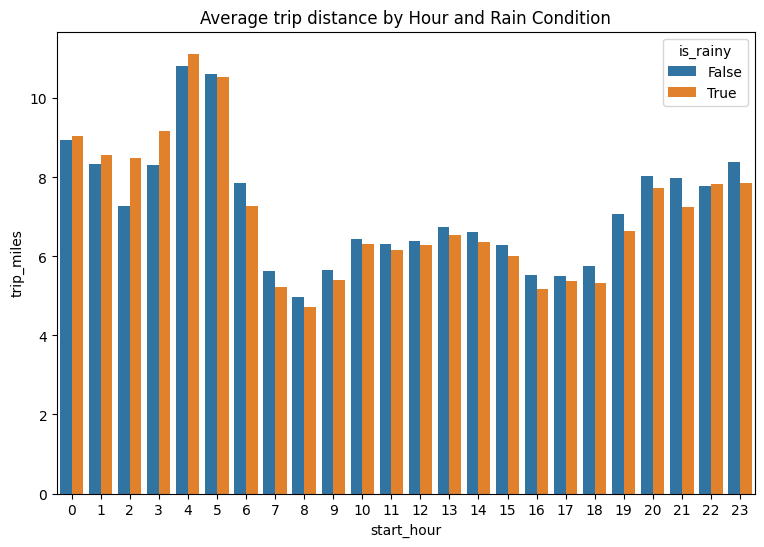

In [ ]:
#| label: fig-rain-distance
#| fig-cap: "Average trip distance by Hour and Rain Condition"

# Average distance per hour and rain status
avg_distance = (
    df.groupby(["start_hour", "is_rainy"])["trip_miles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_distance, x = "start_hour", y="trip_miles", hue = "is_rainy")
plt.title("Average trip distance by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain has a very subtle effect on trip distance. During the day, trips during rain seem to be slightly shorter than when its dry, which might be explained by people not wanting to get wet and taking a taxi for shorter distances than they normally would. The hourly pattern shows longest trips at night (0h, 4-5h), likely airport runs, and shortest trips during midday urban hours (7-9h).

### Average fare per mile per hour, dry vs rainy:

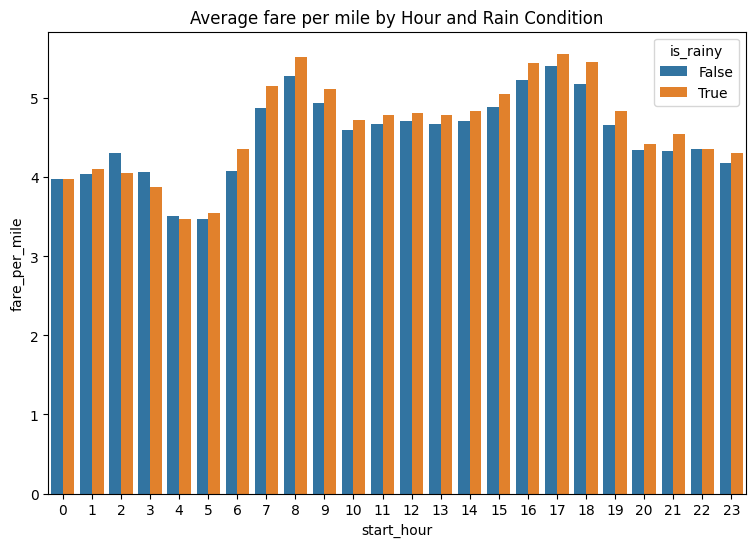

In [ ]:
#| label: fig-rain-fare-per-mile
#| fig-cap: "Average fare per mile by Hour and Rain Condition"

# calculate fare per mile
df['fare_per_mile'] = df['fare'] / df['trip_miles'].replace(0, np.nan)

# Average fare per mile per hour and rain status
avg_fare_per_mile = (
    df.groupby(["start_hour", "is_rainy"])["fare_per_mile"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_fare_per_mile, x = "start_hour", y="fare_per_mile", hue = "is_rainy")
plt.title("Average fare per mile by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain has a very small effect on fare per mile, with the orange bars being a bit higher throughout the day. The hourly pattern shows higher fare per mile during morning and evening peaks (8-9h, 16-18h), which may reflect more stop-and-go traffic increasing time-based fare components relative to distance.

### Average tip rate per hour, dry vs rainy:

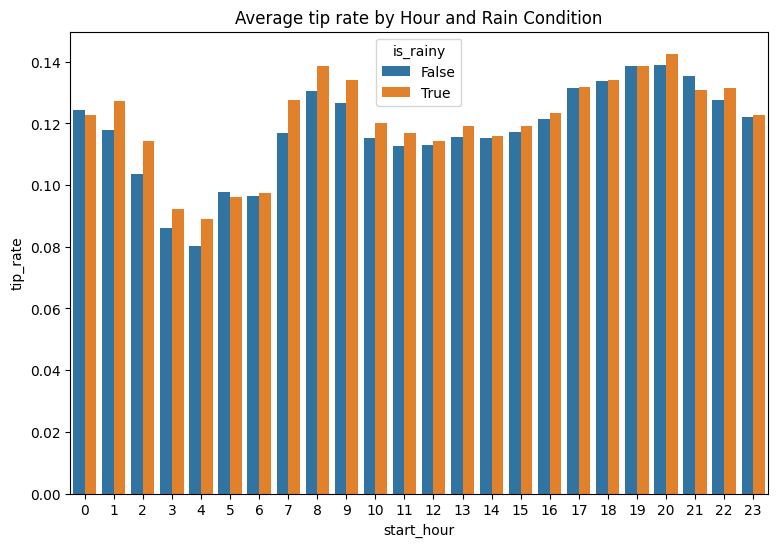

In [ ]:
#| label: fig-rain-tip-rate
#| fig-cap: "Average tip rate by Hour and Rain Condition"

# calculate the tip rate (tips/fare)
df['tip_rate'] = df['tips'] / df['fare']

# Average tip rate per hour and rain status
avg_tip_rate = (
    df.groupby(["start_hour", "is_rainy"])["tip_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_tip_rate, x = "start_hour", y="tip_rate", hue = "is_rainy")
plt.title("Average tip rate by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain slightly increases tip rates at most hours, though the difference is small. Tip rates are lowest in the early morning hours (3-5h) and highest in the morning (8-10h) and evening (19-21h). The rain effect on tipping could reflect gratitude from passengers who were particularly relieved to find a taxi in bad weather.

#### Average idle time per hour, dry vs rainy:

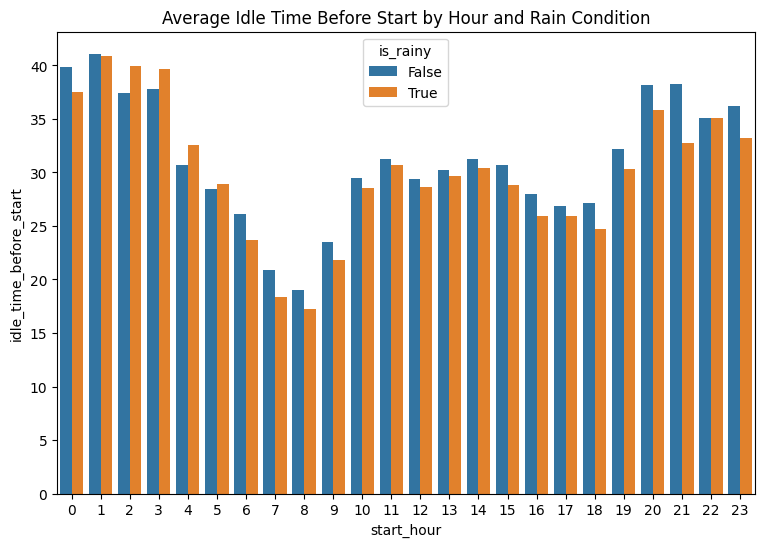

In [ ]:
#| label: fig-rain-idle-time
#| fig-cap: "Average idle time by Hour and Rain Condition"

# Average idle time per hour and rain status
avg_idle_time = (
    df.groupby(["start_hour", "is_rainy"])["idle_time_before_start"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_idle_time, x = "start_hour", y="idle_time_before_start", hue = "is_rainy")
plt.title("Average Idle Time Before Start by Hour and Rain Condition")
plt.show()

#### Interpretation

Rain slightly reduces idle time during most hours. On rainy days demand is higher, so drivers find their next passenger faster and wait less between trips. The hourly pattern shows highest idle times during the night and lows during the rush hours.